# Data Preprocessing & Input Pipeline Preparation

### 🎯 Goal of This Notebook
<pre>
The goal of this notebook is to preprocess crop leaf images and build efficient, Keras-compatible input pipelines
for training, validation, and testing of CNN models.
</pre>
### This notebook ensures:
 - All images are uniformly resized and normalized
 - Data augmentation is applied correctly (train only)
 - Class labels are encoded properly
 - Data loaders are optimized for performance and memory usage


## Clone the GitHub Repository
### 📌 Purpose
<pre>
 - To obtain the complete project structure locally for exploration and experimentation.
</pre>

In [2]:
# Clone the Repository
!git clone https://github.com/sabin74/Agriculture-Crop-Disease-Detection-Advisory-System.git


Cloning into 'Agriculture-Crop-Disease-Detection-Advisory-System'...
remote: Enumerating objects: 97172, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 97172 (delta 8), reused 22 (delta 7), pack-reused 97133 (from 3)
Receiving objects: 100% (97172/97172), 1.62 GiB | 28.84 MiB/s, done.
Resolving deltas: 100% (458/458), done.
Updating files: 100% (94786/94786), done.


In [3]:
# Set Project Root
import os
os.chdir("/content/Agriculture-Crop-Disease-Detection-Advisory-System")
print("Current Directory: ", os.getcwd())

Current Directory:  /content/Agriculture-Crop-Disease-Detection-Advisory-System


## Import Required Libraries
### 📌 Purpose

Load all libraries required for image preprocessing, input pipeline preparation, augmentation, and sanity checks.

In [1]:
# System & Path Handling
import os
from pathlib import Path

# Numerical# System & Path Handling
import os
from pathlib import Path

# Numerical
import numpy as np

# TensorFlow / Keras
import tensorflow as tf
import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Visualization (Sanity checks)
import matplotlib.pyplot as plt

# Config saving
import json
import yaml

# Additional utilities
import warnings
warnings.filterwarnings("ignore")

# Visualization Settings
plt.style.use("seaborn-v0_8")
plt.rcParams['figure.figsize'] = (12, 8)
import numpy as np

# TensorFlow / Keras
import tensorflow as tf
import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Visualization (Sanity checks)
import matplotlib.pyplot as plt

# Config saving
import json
import yaml

In [4]:
# Environment Verification
print("TensorFlow Version: ", tf.__version__)
print("Keras Version: ", keras.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version:  2.19.0
Keras Version:  3.10.0
GPU Available: []


##Define Dataset Paths
### 📌 Purpose

Centralize all dataset directory paths in one place so they can be reused consistently throughout the notebook.

In [5]:
# Define Dataset Root Directory
DATASET_ROOT = Path("Modeling/Crop Disease Dataset")

# Define Individual Dataset Splits
TRAIN_DIR = DATASET_ROOT / "train"
TEST_DIR = DATASET_ROOT / "test"
VALID_DIR = DATASET_ROOT / "valid"

# Display Paths
print("📂 Dataset Structure:")
print(f"  Train Directory: {TRAIN_DIR}")
print(f"  Test Directory: {TEST_DIR}")
print(f"  Valid Directory: {VALID_DIR}")
print(f"  Dataset Root: {DATASET_ROOT}")

# Verify directories exist
print("\n🔍 Directory Verification:")
for dir_name, dir_path in [("Train", TRAIN_DIR), ("Valid", VALID_DIR), ("Test", TEST_DIR)]:
    if dir_path.exists():
        print(f"  ✓ {dir_name}: Found ({len(list(dir_path.iterdir()))} items)")
    else:
        print(f"  ✗ {dir_name}: NOT FOUND!")

📂 Dataset Structure:
  Train Directory: Modeling/Crop Disease Dataset/train
  Test Directory: Modeling/Crop Disease Dataset/test
  Valid Directory: Modeling/Crop Disease Dataset/valid
  Dataset Root: Modeling/Crop Disease Dataset

🔍 Directory Verification:
  ✓ Train: Found (13 items)
  ✓ Valid: Found (13 items)
  ✓ Test: Found (45 items)


## Define Image Parameters
### 📌 Purpose

Standardize image inputs so all CNN models receive uniform data, ensuring:

 - Consistent tensor shapes
 - Model compatibility
 - Stable training behavior

In [6]:
# Image Parameters
IMAGE_SIZE = (224, 224)      # Standard size for MobileNetV2, ResNet, etc.
BATCH_SIZE = 32              # Optimized for Colab/GPU memory
COLOR_MODE = 'rgb'           # 3-channel color images

print("🖼️ Image Parameters:")
print(f"  Image Size: {IMAGE_SIZE}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Color Mode: {COLOR_MODE}")
print(f"  Total Pixels: {IMAGE_SIZE[0]} × {IMAGE_SIZE[1]} = {IMAGE_SIZE[0]*IMAGE_SIZE[1]:,}")

🖼️ Image Parameters:
  Image Size: (224, 224)
  Batch Size: 32
  Color Mode: rgb
  Total Pixels: 224 × 224 = 50,176


## Data Augmentation Strategy
### 📌 Purpose

Increase data diversity and model generalization by applying realistic transformations only to training images.

In [7]:
# Training Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,              # Normalize pixel values to [0, 1]
    rotation_range=25,           # Random rotation up to 25 degrees
    zoom_range=0.2,              # Random zoom up to 20%
    horizontal_flip=True,        # Random horizontal flip
    brightness_range=(0.8, 1.2), # Random brightness adjustment
    width_shift_range=0.1,       # Random horizontal shift up to 10%
    height_shift_range=0.1,      # Random vertical shift up to 10%
    fill_mode="nearest"          # Fill empty pixels with nearest
)

# Validation and Test Data (No augmentation, only rescaling)
valid_test_datagen = ImageDataGenerator(
    rescale=1./255              # Only normalization, no augmentation
)

print("✅ Data Augmentation Strategy Defined")
print("\n📊 Training Augmentations:")
print("  • Rotation: ±25°")
print("  • Zoom: ±20%")
print("  • Horizontal Flip: Yes")
print("  • Brightness: 80-120%")
print("  • Shift: ±10% (width & height)")
print("\n📊 Validation/Test:")
print("  • Only normalization (no augmentation)")

✅ Data Augmentation Strategy Defined

📊 Training Augmentations:
  • Rotation: ±25°
  • Zoom: ±20%
  • Horizontal Flip: Yes
  • Brightness: 80-120%
  • Shift: ±10% (width & height)

📊 Validation/Test:
  • Only normalization (no augmentation)


## Create Training Data Generator
### 📌 Purpose

Load training images dynamically from disk, apply data augmentation, and generate:

 - Image batches
 - One-hot encoded class labels

In [8]:
# Training Data Generator
print("🔄 Creating Training Data Generator...")
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    color_mode=COLOR_MODE,
    class_mode="categorical",
    shuffle=True,
    seed=42  # For reproducibility
)

print(f"✅ Training Generator Created Successfully!")
print(f"  Number of Classes: {train_generator.num_classes}")
print(f"  Number of Samples: {train_generator.samples:,}")
print(f"  Batch Size: {train_generator.batch_size}")
print(f"  Steps per Epoch: {train_generator.samples // train_generator.batch_size}")

🔄 Creating Training Data Generator...
Found 74880 images belonging to 13 classes.
✅ Training Generator Created Successfully!
  Number of Classes: 13
  Number of Samples: 74,880
  Batch Size: 32
  Steps per Epoch: 2340


In [16]:
# Display Class Indices
print("📋 Class Indices (First 10):")
class_indices = train_generator.class_indices
for class_name, idx in list(class_indices.items())[:10]:
    print(f"  {idx:3d}: {class_name}")

print(f"\nTotal classes indexed: {len(class_indices)}")

📋 Class Indices (First 10):
    0: apple
    1: banana
    2: cherry
    3: coffee
    4: corn
    5: grape
    6: mango
    7: orange
    8: peach
    9: potato

Total classes indexed: 13


## Create Validation Data Generator
###📌 Purpose

Provide unbiased evaluation data during training by:

 - Applying no augmentation
 - Using only rescaling
 - Preserving deterministic order of samples

In [10]:
# Validation Data Generator
print("🔄 Creating Validation Data Generator...")
valid_generator = valid_test_datagen.flow_from_directory(
    VALID_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    color_mode=COLOR_MODE,
    class_mode="categorical",
    shuffle=False  # Important: Don't shuffle validation data
)

print(f"✅ Validation Generator Created Successfully!")
print(f"  Number of Classes: {valid_generator.num_classes}")
print(f"  Number of Samples: {valid_generator.samples:,}")
print(f"  Batch Size: {valid_generator.batch_size}")

🔄 Creating Validation Data Generator...
Found 19804 images belonging to 13 classes.
✅ Validation Generator Created Successfully!
  Number of Classes: 13
  Number of Samples: 19,804
  Batch Size: 32


In [17]:
# Verify Train-Validation Consistency
print("🔍 Train-Validation Consistency Check:")

if train_generator.num_classes == valid_generator.num_classes:
    print(f"  ✓ Class count matches: {train_generator.num_classes}")
else:
    print(f"  ✗ Class count mismatch!")
    print(f"    Train: {train_generator.num_classes}, Valid: {valid_generator.num_classes}")

# Check if all validation classes exist in training
train_classes = set(train_generator.class_indices.keys())
valid_classes = set(valid_generator.class_indices.keys())

missing_in_train = valid_classes - train_classes
if missing_in_train:
    print(f"  ✗ Validation classes missing in training: {len(missing_in_train)}")
    for cls in list(missing_in_train)[:5]:
        print(f"    - {cls}")
else:
    print(f"  ✓ All validation classes exist in training set")

🔍 Train-Validation Consistency Check:
  ✓ Class count matches: 13
  ✓ All validation classes exist in training set


## Verify Class Labels & Encoding
📌 Purpose

Ensure that class names → numeric indices mapping is Correct,
Consistent & Reusable across training, evaluation and deployment

In [12]:
# Save Class Indices for Future Use
CONFIG_DIR = Path("Modeling/configs")
CONFIG_DIR.mkdir(parents=True, exist_ok=True)

# Save class indices to JSON
with open(CONFIG_DIR / "classes.json", "w") as f:
    json.dump(class_indices, f, indent=4)

print(f"✅ Class indices saved to: {CONFIG_DIR / 'classes.json'}")

# Also save reverse mapping (index → class name)
class_names = {v: k for k, v in class_indices.items()}
with open(CONFIG_DIR / "class_names.json", "w") as f:
    json.dump(class_names, f, indent=4)

print(f"✅ Class names mapping saved to: {CONFIG_DIR / 'class_names.json'}")

✅ Class indices saved to: Modeling/configs/classes.json
✅ Class names mapping saved to: Modeling/configs/class_names.json


In [13]:
# Display detailed class information
print("📊 Class Distribution Summary:")
print(f"  Total classes: {train_generator.num_classes}")
print(f"  Training samples: {train_generator.samples:,}")
print(f"  Validation samples: {valid_generator.samples:,}")
print(f"  Train/Validation ratio: {train_generator.samples/valid_generator.samples:.1f}:1")

# Count classes per crop (if using nested structure)
print("\n🌾 Estimated Crop Distribution:")
# This assumes class names follow "Crop___Disease" format
crop_counter = {}
for class_name in class_indices.keys():
    if '___' in class_name:
        crop = class_name.split('___')[0]
        crop_counter[crop] = crop_counter.get(crop, 0) + 1

for crop, count in list(crop_counter.items())[:10]:  # Show top 10
    print(f"  {crop}: {count} classes")

📊 Class Distribution Summary:
  Total classes: 13
  Training samples: 74,880
  Validation samples: 19,804
  Train/Validation ratio: 3.8:1

🌾 Estimated Crop Distribution:


## Sanity Check – Visualize Augmented Images
### 📌 Purpose

Visually confirm that:

 - Images are resized to 224×224
 - Augmentations are applied realistically
 - Labels correctly match the images

In [18]:
# Fetch a batch of augmented images
images, labels = next(train_generator)

print("🔍 Sanity Check - Augmented Batch:")
print(f"  Images shape: {images.shape}")
print(f"  Labels shape: {labels.shape}")
print(f"  Pixel range: [{images.min():.3f}, {images.max():.3f}]")
print(f"  Data type: {images.dtype}")

🔍 Sanity Check - Augmented Batch:
  Images shape: (32, 224, 224, 3)
  Labels shape: (32, 13)
  Pixel range: [0.000, 1.000]
  Data type: float32


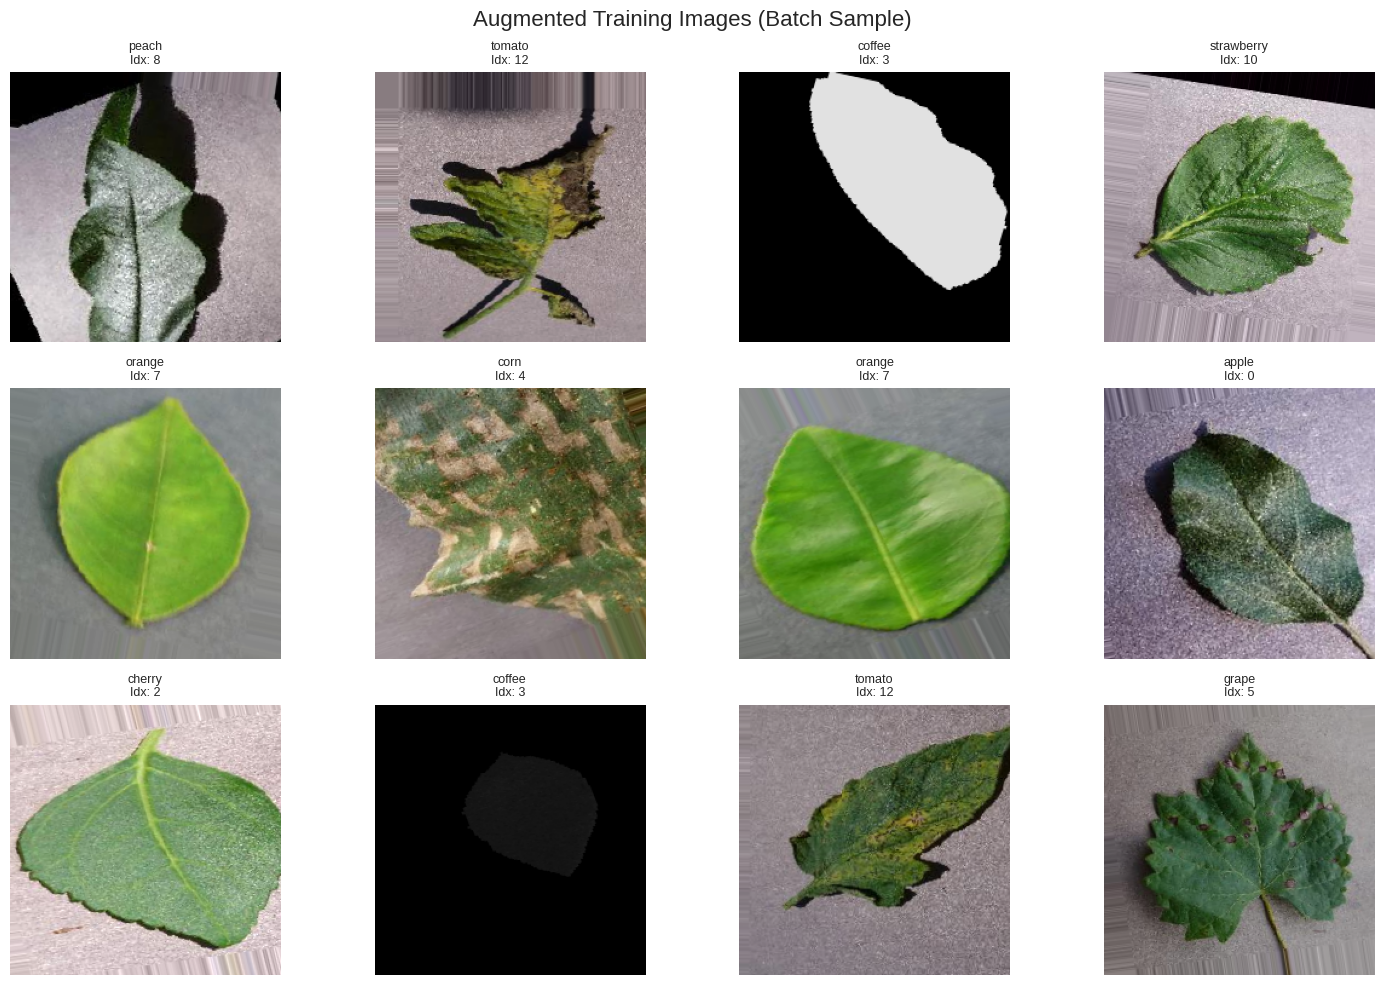

✅ Augmentation visualization saved to: Modeling/reports/figures/preprocessing/augmented_images_sample.png


In [19]:
# Plot Augmented Images
plt.figure(figsize=(15, 10))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    # Display image (already normalized to [0,1])
    plt.imshow(images[i])

    # Get label
    label_index = np.argmax(labels[i])
    label_name = class_names[label_index]

    # Truncate long class names for display
    display_name = label_name if len(label_name) <= 30 else label_name[:27] + "..."
    plt.title(f"{display_name}\nIdx: {label_index}", fontsize=9)
    plt.axis("off")

plt.suptitle("Augmented Training Images (Batch Sample)", fontsize=16, y=0.98)
plt.tight_layout()

# Save the figure
FIGURES_DIR = Path("Modeling/reports/figures/preprocessing")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES_DIR / "augmented_images_sample.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"✅ Augmentation visualization saved to: {FIGURES_DIR / 'augmented_images_sample.png'}")

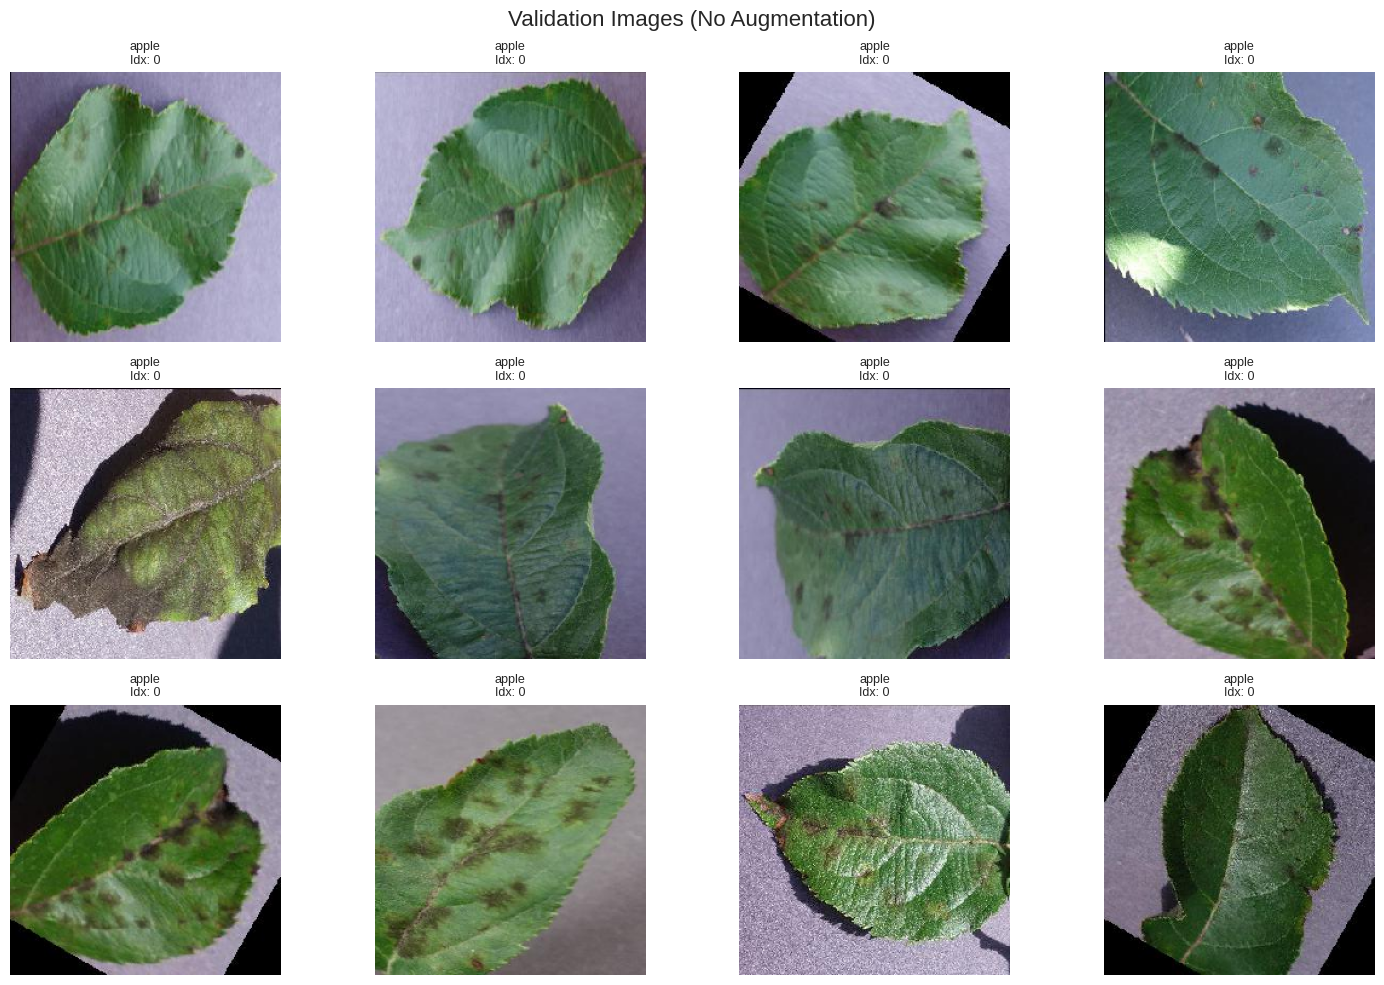

✅ Validation images saved to: Modeling/reports/figures/preprocessing/validation_images_sample.png


In [20]:
# Fetch a batch of validation images (no augmentation)
val_images, val_labels = next(valid_generator)

plt.figure(figsize=(15, 10))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(val_images[i])

    label_index = np.argmax(val_labels[i])
    label_name = class_names[label_index]

    display_name = label_name if len(label_name) <= 30 else label_name[:27] + "..."
    plt.title(f"{display_name}\nIdx: {label_index}", fontsize=9)
    plt.axis("off")

plt.suptitle("Validation Images (No Augmentation)", fontsize=16, y=0.98)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "validation_images_sample.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"✅ Validation images saved to: {FIGURES_DIR / 'validation_images_sample.png'}")

## Save Preprocessing and Configuration

In [22]:
# Create comprehensive configuration dictionary
import pandas as pd

config = {
    "dataset": {
        "train_dir": str(TRAIN_DIR),
        "valid_dir": str(VALID_DIR),
        "test_dir": str(TEST_DIR),
        "total_classes": train_generator.num_classes,
        "train_samples": train_generator.samples,
        "valid_samples": valid_generator.samples
    },
    "image": {
        "size": IMAGE_SIZE,
        "color_mode": COLOR_MODE,
        "normalization": "1./255"
    },
    "training": {
        "batch_size": BATCH_SIZE,
        "steps_per_epoch": train_generator.samples // BATCH_SIZE,
        "validation_steps": valid_generator.samples // BATCH_SIZE
    },
    "augmentation": {
        "train": {
            "rotation_range": 25,
            "zoom_range": 0.2,
            "horizontal_flip": True,
            "brightness_range": [0.8, 1.2],
            "width_shift_range": 0.1,
            "height_shift_range": 0.1,
            "fill_mode": "nearest"
        },
        "validation_test": {
            "augmentation": "none",
            "only_rescale": True
        }
    },
    "generator": {
        "class_mode": "categorical",
        "shuffle": {
            "train": True,
            "validation": False
        },
        "seed": 42
    },
    "metadata": {
        "creation_date": str(pd.Timestamp.now()),
        "tensorflow_version": tf.__version__,
        "keras_version": keras.__version__
    }
}

# Save configuration to YAML
with open(CONFIG_DIR / "preprocessing_config.yaml", "w") as f:
    yaml.dump(config, f, indent=2, default_flow_style=False)

print(f"✅ Preprocessing configuration saved to: {CONFIG_DIR / 'preprocessing_config.yaml'}")

# Also save as JSON for easier reading
with open(CONFIG_DIR / "preprocessing_config.json", "w") as f:
    json.dump(config, f, indent=2)

print(f"✅ Preprocessing configuration saved to: {CONFIG_DIR / 'preprocessing_config.json'}")

✅ Preprocessing configuration saved to: Modeling/configs/preprocessing_config.yaml
✅ Preprocessing configuration saved to: Modeling/configs/preprocessing_config.json


In [23]:
# Display configuration summary
print("📋 CONFIGURATION SUMMARY")
print("=" * 50)
print(f"Image Processing:")
print(f"  • Size: {config['image']['size']}")
print(f"  • Color: {config['image']['color_mode']}")
print(f"  • Normalization: {config['image']['normalization']}")
print(f"\nDataset:")
print(f"  • Classes: {config['dataset']['total_classes']}")
print(f"  • Train samples: {config['dataset']['train_samples']:,}")
print(f"  • Valid samples: {config['dataset']['valid_samples']:,}")
print(f"  • Ratio: {config['dataset']['train_samples']/config['dataset']['valid_samples']:.1f}:1")
print(f"\nTraining:")
print(f"  • Batch size: {config['training']['batch_size']}")
print(f"  • Steps/epoch: {config['training']['steps_per_epoch']}")
print(f"  • Validation steps: {config['training']['validation_steps']}")
print(f"\nAugmentation:")
print(f"  • Rotation: ±{config['augmentation']['train']['rotation_range']}°")
print(f"  • Zoom: ±{config['augmentation']['train']['zoom_range']*100}%")
print(f"  • Horizontal flip: {config['augmentation']['train']['horizontal_flip']}")

📋 CONFIGURATION SUMMARY
Image Processing:
  • Size: (224, 224)
  • Color: rgb
  • Normalization: 1./255

Dataset:
  • Classes: 13
  • Train samples: 74,880
  • Valid samples: 19,804
  • Ratio: 3.8:1

Training:
  • Batch size: 32
  • Steps/epoch: 2340
  • Validation steps: 618

Augmentation:
  • Rotation: ±25°
  • Zoom: ±20.0%
  • Horizontal flip: True


In [24]:
import shutil
from google.colab import files

print("📦 Creating configuration archive...")

# Create a temporary directory for archiving
TEMP_ARCHIVE_DIR = Path("temp_config_archive")
TEMP_ARCHIVE_DIR.mkdir(exist_ok=True)

# Copy all configuration files
config_files_to_archive = [
    CONFIG_DIR / "classes.json",
    CONFIG_DIR / "class_names.json",
    CONFIG_DIR / "preprocessing_config.yaml",
    CONFIG_DIR / "preprocessing_config.json",
    FIGURES_DIR / "augmented_images_sample.png",
    FIGURES_DIR / "validation_images_sample.png"
]

for file_path in config_files_to_archive:
    if file_path.exists():
        # Create subdirectories in archive if needed
        dest_path = TEMP_ARCHIVE_DIR / file_path.relative_to(CONFIG_DIR.parent)
        dest_path.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(file_path, dest_path)
        print(f"  ✓ Added: {file_path.name}")

# Also add dataset summary from Notebook 1 if exists
dataset_summary = Path("Modeling/reports/dataset_summary.json")
if dataset_summary.exists():
    shutil.copy2(dataset_summary, TEMP_ARCHIVE_DIR / "dataset_summary.json")
    print(f"  ✓ Added: dataset_summary.json")

# Create ZIP archive
output_filename = "preprocessing_configs"
shutil.make_archive(output_filename, 'zip', TEMP_ARCHIVE_DIR)

print(f"\n✅ Archive created: {output_filename}.zip")
print(f"   Size: {os.path.getsize(output_filename + '.zip') / 1024:.1f} KB")

# Clean up temporary directory
shutil.rmtree(TEMP_ARCHIVE_DIR)

print("\n⬇️  Downloading archive...")
files.download(f'{output_filename}.zip')

📦 Creating configuration archive...
  ✓ Added: classes.json
  ✓ Added: class_names.json
  ✓ Added: preprocessing_config.yaml
  ✓ Added: preprocessing_config.json
  ✓ Added: augmented_images_sample.png
  ✓ Added: validation_images_sample.png

✅ Archive created: preprocessing_configs.zip
   Size: 3086.0 KB

⬇️  Downloading archive...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>